<a href="https://colab.research.google.com/github/Alexis28002/Investigaci-n_de_operaciones/blob/main/Networkx1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libreria **NetworkX** en Python
*Investigacion de operaciones*

*Ingenieria Matematica*

*Alexis Alfaro Ramirez*

##Contenido
1.-[Fundamentos de **NetworkX**](#1)

2.-[Árbol de expansión mínima](#2)

3.-[Ruta más corta](#3)

4.-[Flujo máximo](#4)


<a name="1"></a>
#**1.-Fundamentos de NetworkX**

NetworkX es una libreria de Python que se utiliza mayormente para crear, dibujar y analizar redes creadas apartir de nodos y aristas que se unen para generar un grafo.

Los nodos pueden representar cualquier cosa ya sea algun objeto, una persona, una ciudad, etc; Y las aristas tambien pueden representarse como una conexion ya sea un cable, una carretera, etc.

Un ejemplo muy practico en la vida real son las redes sociales, cada usuario representa un nodo en particular y las aristas que se conectan entre ellas son las conexiones de amistad que tiene cada nodo, osea cada persona.


*Para comenzar a utilizarla tienes que corroborar que la libreria este previamente instalada, despues solo tienes que importarla de la siguiente manera:*

In [1]:
import networkx as nx

Asimismo para graficar las redes creadas apartir de **NetworkX** necesitas tener instalada la libreria **Matplotlib**, y despues importarla.

In [2]:
import matplotlib.pyplot as plt

#Tipos de Red
Existen 4 tipos de redes, que en mejores palabras significa que hay 4 distintas formas de conectar los nodos, estas son:


|Tipo|Descripcion|Ejemplo|
|---|---|---|
|`nx.Graph()`| No dirigido, una arista por par de nodos|Calles de doble sentido
|`nx.DiGraph()`|Dirigido|Calle de un solo sentido
|`nx.MultiGraph()`|No dirigido, permite aristas paralelas|Varias calles distintas entre los mismo lugares
|`nx.MultiDiGraph()`|Dirigido, permite aristas paralelas|Varias calles distintas entre dos mismos lugares, pero con sentido

Asimismo a las aristas puedes ponerles **un peso** (`weight`), ya sea que represente distancia, peso, tiempo, etc.

*Para comenzar a construir nuestro primer grafo debemos conocer antes los comandos basicos, que son:*

| Comando | Qué hace |
|---|---|
| `G.add_node(n)` / `G.add_nodes_from([...])` | Agrega uno o varios nodos |
| `G.add_edge(u, v, weight=w)` | Agrega la arista $u\to v$ con atributo `weight` |
| `G.add_weighted_edges_from([(u, v, w), ...])` | Agrega varias aristas con peso a la vez |
| `G.nodes`, `G.edges(data=True)` | Consultan nodos y aristas (con sus atributos) |
| `G[u][v]["weight"]` | Lee el atributo de una arista |

Un ejemplo para crear nuestra primera red seria el siguiente:

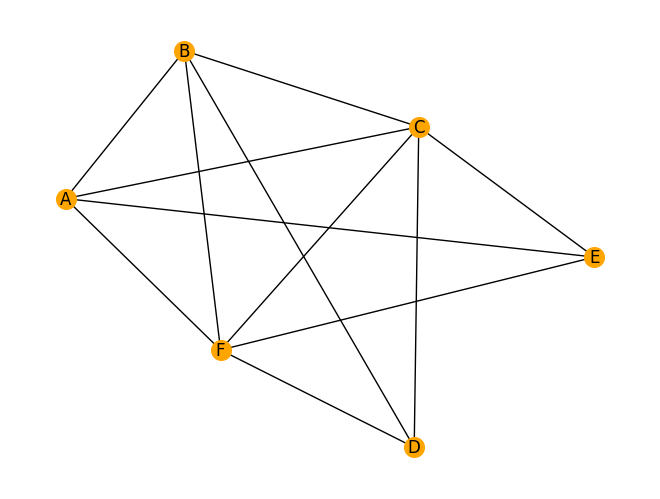

In [48]:
G = nx.Graph(name="Mi red")
G.add_node("A", color="naranja")
G.add_nodes_from(["B", "C","D","E","F"])
G.add_edges_from([("A", "C"), ("C", "A"),("A","E"),("C","E"),("A", "B"), ("B", "C"),("B","F"),("D","B"),("D","C"),("E","F"),("A","F"),("D","F"),("F","C")])
pos = nx.spring_layout(G, seed=42)
nx.draw(G,with_labels=True,node_color="orange",node_size=200)
plt.show()

<a name="2"></a>
#**2.-Árbol de expansión mínima (MST)**

# *Formulación*

Dada una red **no dirigida** $G=(V,E)$ con pesos $w_{ij}\ge 0$, se busca un subconjunto de aristas $T\subseteq E$ que conecte todos los nodos sin formar ciclos y que minimice el peso total:

$$\min_{T}\ \sum_{(i,j)\in T} w_{ij} \qquad \text{s.a. } T \text{ conecta a todos los nodos y } |T| = |V|-1.$$

# *Comandos de NetworkX*

| Función | Descripción |
|---|---|
| `nx.minimum_spanning_tree(G, weight="weight", algorithm="kruskal")` | Devuelve un nuevo grafo con el árbol. `algorithm` puede ser `"kruskal"`, `"prim"` o `"boruvka"` |
| `T.edges(data=True)` | Aristas del árbol con sus pesos |
| `T.size(weight="weight")` | Suma de los pesos de las aristas (costo total) |

*Comenzamos escribiendo el codigo del grafo "1_a" para poder utilizar el método del árbol de expansión y resolverlo.*

In [50]:
G=nx.Graph()
G.add_weighted_edges_from([(1, 2, 5), (1, 3, 1), (2, 3, 2),
    (2, 4, 7), (2, 5, 1), (2, 6, 6),
    (3, 4, 6), (3, 5, 7), (4, 5, 3),
    (4, 6, 4), (4, 7, 6), (5, 6, 5),
    (5, 7, 9), (6, 7, 2)])

In [51]:
T = nx.minimum_spanning_tree(G, algorithm="kruskal")

print("Aristas del árbol:", sorted(T.edges(data="weight")))
print("Costo total:", T.size(weight="weight"))

Aristas del árbol: [(1, 3, 1), (2, 3, 2), (2, 5, 1), (4, 5, 3), (4, 6, 4), (6, 7, 2)]
Costo total: 13.0


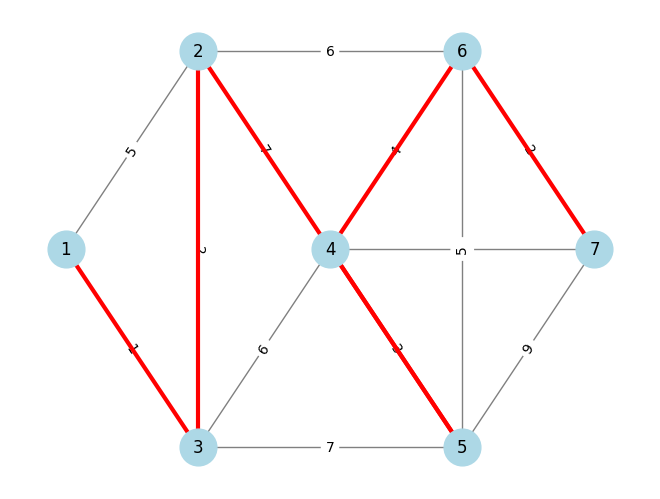

In [52]:
pos = {1: (0, 0), 2: (1, 1), 3: (1, -1), 4: (2, 0), 5: (3, -1), 6: (3, 1), 7: (4, 0)}

nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=700, edge_color="gray")
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "weight"))
nx.draw_networkx_edges(G, pos, edgelist=T.edges, edge_color="red", width=3)  # el árbol en rojo
plt.show()

<a name="3"></a>
#**3.-Ruta más corta**

# *Formulación*

Sea $G=(V,A)$ una red dirigida con distancias $c_{ij}$. Para encontrar la ruta más corta del nodo origen $s$ al destino $t$, se define $x_{ij}=1$ si el arco $(i,j)$ pertenece a la ruta y $0$ en otro caso:

$$\min \sum_{(i,j)\in A} c_{ij}\,x_{ij}$$

$$\text{s.a.}\quad \sum_{j} x_{ij}-\sum_{j} x_{ji}=\begin{cases}1 & i=s\\ -1 & i=t\\ 0 & \text{en otro caso}\end{cases}\qquad x_{ij}\in\{0,1\}$$

Aquí se busca la ruta del **nodo 1 al nodo 7** de la red dirigida A.

# *Comandos de NetworkX*

| Función | Descripción |
|---|---|
| `nx.shortest_path(G, source, target, weight="weight")` | Una ruta más corta (lista de nodos) |
| `nx.shortest_path_length(G, source, target, weight="weight")` | Longitud de esa ruta |
| `nx.all_shortest_paths(G, source, target, weight="weight")` | Generador con **todas** las rutas óptimas (si hay empates) |
| `nx.dijkstra_path(...)` | Algoritmo de Dijkstra (pesos $\ge 0$) |
| `nx.bellman_ford_path(...)` | Alternativa si hay pesos negativos |

Sin el argumento `weight`, NetworkX cuenta *número de arcos* en lugar de distancia.

*Continuamos con el siguiente método y para poder resolverlo tenemos que escribir la red pero ahora utilizando **DiGraph**, ya que en este ejercicio la red si va dirigida.*

In [53]:
G = nx.DiGraph()
G.add_weighted_edges_from([(1, 2, 5), (1, 3, 1), (3, 2, 2),
    (2, 6, 6), (6, 2, 7), (2, 4, 7), (2, 5, 1),
    (3, 4, 6), (4, 3, 7), (3, 5, 7),
    (5, 4, 3), (4, 6, 4), (4, 7, 6),
    (5, 6, 5), (5, 7, 9), (6, 7, 2)])


In [54]:
origen, destino = 1, 7

ruta = nx.shortest_path(G, source=origen, target=destino, weight="weight")
distancia = nx.shortest_path_length(G, source=origen, target=destino, weight="weight")

print("Ruta más corta:", ruta)
print("Distancia total:", distancia)

Ruta más corta: [1, 3, 2, 6, 7]
Distancia total: 11


En este ejercicio hay 2 rutas que empatan, ya que al sumarse cada una se obtiene el mismo resultado.

In [55]:
todas = list(nx.all_shortest_paths(G, origen, destino, weight="weight"))
print(todas)

[[1, 3, 2, 6, 7], [1, 3, 2, 5, 6, 7]]


*Dibujamos la red:*

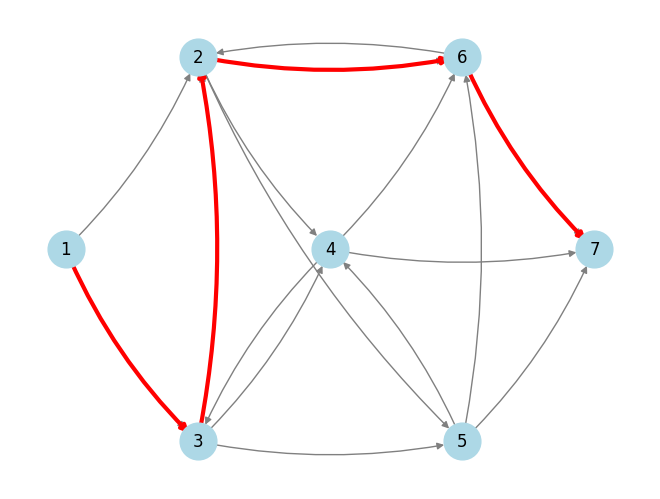

In [58]:
pos = {1: (0, 0), 2: (1, 1), 3: (1, -1), 4: (2, 0), 5: (3, -1), 6: (3, 1), 7: (4, 0)}

arcos_ruta = list(zip(ruta, ruta[1:]))   # convierte [1,3,2,6,7] en [(1,3),(3,2),(2,6),(6,7)]

nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=700,
        edge_color="gray", connectionstyle="arc3,rad=0.1")
nx.draw_networkx_edges(G, pos, edgelist=arcos_ruta, edge_color="red", width=3,
                       connectionstyle="arc3,rad=0.1")
plt.show()

<a name="4"></a>
#**4.-Flujo Máximo**

#*Formulación*

Sea $G=(V,A)$ una red dirigida con capacidades $u_{ij}$, un nodo fuente $s$ y un nodo sumidero $t$. Se busca enviar el mayor flujo posible de $s$ a $t$:

$$\max\ v$$

$$\text{s.a.}\quad \sum_{j} x_{ij}-\sum_{j} x_{ji}=\begin{cases}v & i=s\\ -v & i=t\\ 0 & \text{en otro caso}\end{cases}\qquad 0\le x_{ij}\le u_{ij}\ \ \forall (i,j)\in A$$

Por el **teorema flujo máximo – corte mínimo**, el valor del flujo máximo es igual a la capacidad del corte $(S,\bar S)$ de menor capacidad: $\;v^*=\min_{s\in S,\ t\notin S}\sum_{i\in S,\,j\in\bar S}u_{ij}$.

# *Comandos de NetworkX*

| Función | Descripción |
|---|---|
| `G.add_edge(u, v, capacity=c)` | Las capacidades se guardan en el atributo `capacity` (nombre obligatorio) |
| `nx.maximum_flow(G, s, t)` | Devuelve `(valor, diccionario_de_flujos)` |
| `nx.maximum_flow_value(G, s, t)` | Solo el valor del flujo máximo |
| `nx.minimum_cut(G, s, t)` | Devuelve `(capacidad, (S, T))`: el corte mínimo |

Para poder utilizar este método escribimos el codigo de la red *"1_b"* y lo implementamos.

In [63]:
G = nx.DiGraph()
capacidades = [(1, 2, 8), (1, 3, 14), (1, 5, 4),(2, 3, 5), (2, 4, 7), (2, 5, 6),(3, 2, 10), (3, 4, 9), (3, 5, 10),(4, 2, 6), (4, 3, 7), (4, 5, 5)]
for u, v, c in capacidades:
    G.add_edge(u, v, capacity=c)


In [64]:
origen, destino = 1, 5

valor, flujo = nx.maximum_flow(G, origen, destino)

print("Flujo máximo:", valor)
for u in flujo:
    for v, f in flujo[u].items():
        if f > 0:
            print(f"  {u} → {v}: {f} de {G[u][v]['capacity']}")

Flujo máximo: 25
  1 → 2: 7 de 8
  1 → 3: 14 de 14
  1 → 5: 4 de 4
  2 → 3: 2 de 5
  2 → 5: 6 de 6
  3 → 4: 6 de 9
  3 → 5: 10 de 10
  4 → 2: 1 de 6
  4 → 5: 5 de 5


*Verificamos con el corte mínimo*

In [65]:
valor_corte, (S, T) = nx.minimum_cut(G, origen, destino)
print("Corte mínimo:", valor_corte)
print("Lado del origen:", sorted(S), " Lado del destino:", sorted(T))

Corte mínimo: 25
Lado del origen: [1, 2, 3, 4]  Lado del destino: [5]


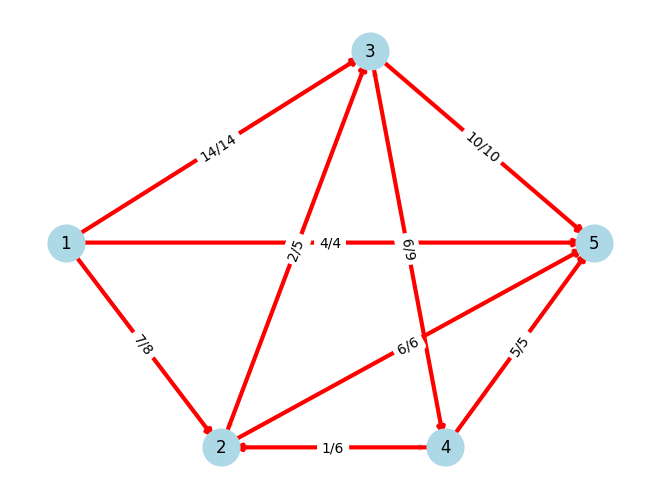

In [66]:
pos = {1: (0, 0), 2: (1.25, -1.6), 3: (2.45, 1.5), 4: (3.05, -1.6), 5: (4.25, 0)}

arcos_con_flujo = [(u, v) for u in flujo for v, f in flujo[u].items() if f > 0]
etiquetas = {(u, v): f"{flujo[u][v]}/{G[u][v]['capacity']}" for u, v in arcos_con_flujo}

nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=700, edge_color="lightgray")
nx.draw_networkx_edges(G, pos, edgelist=arcos_con_flujo, edge_color="red", width=3)
nx.draw_networkx_edge_labels(G, pos, edge_labels=etiquetas)   # muestra flujo/capacidad
plt.show()